# 从零实线线性回归算法

## 生成数据集
使用线性参数模型$ w = [2, -3.4]^T $，b = 4.2 噪声项$ \epsilon $生成数据集以及标签:  
$ y = Xw + b + \epsilon $  
假设$ \epsilon \sim N(0, 0.01) $，则$ y \sim N(Xw + b, 0.01) $。  
最后的y向量和X的第一列呈正相关，和X的第二列呈现负相关。

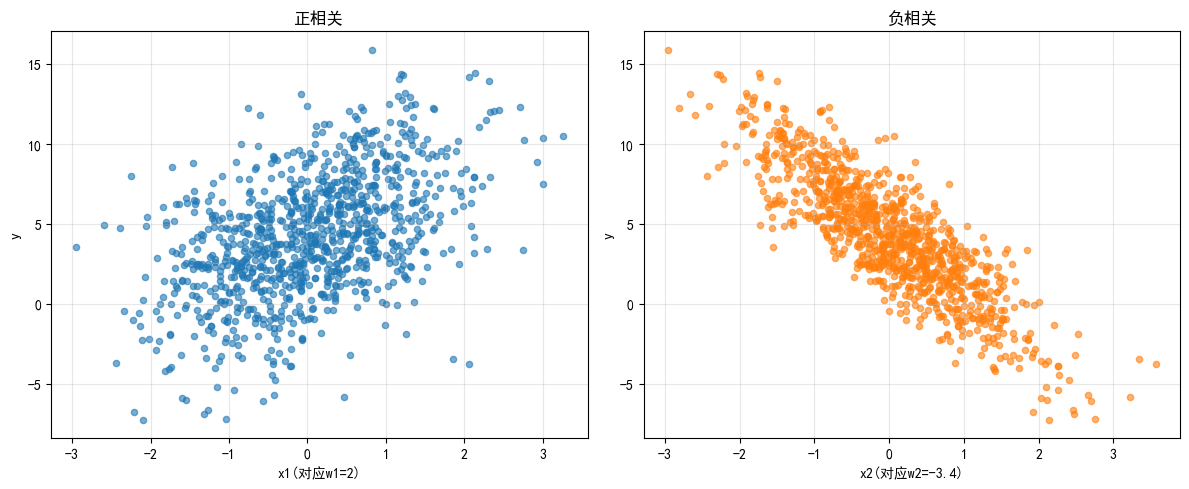

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False
import random
def synthetic_data(w, b, num_samples):
    """生成模拟数据集"""
    X = torch.normal(0, 1, (num_samples, len(w)))  # 生成形状为（num_samples, len(w)）的符合标准正态分布的随机矩阵
    y = torch.matmul(X, w) + b # 这里用的是torch里面的矩阵乘法 返回的形状（num_samples,）
    y = y + torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))  # 返回X和y，y的形状为(num_samples, 1)

true_w = torch.tensor([2, -3.4])  # 两列，对应X矩阵的两列，表示特征
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
# w1大于0，w2小于0，说明w1对y有正影响，w2对y有负影响
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(features[:, 0].numpy(), labels.numpy(), alpha=0.6, s=20, color='#1f77b4')
plt.xlabel('x1(对应w1=2)')
plt.ylabel('y')
plt.title('正相关')
plt.grid(True, alpha=0.3) # alpha表示网格透明度，True表示显示网格
# 负相关
plt.subplot(1, 2, 2)
plt.scatter(features[:, 1].numpy(), labels.numpy(), alpha=0.6, s=20, color='#ff7f0e')
plt.xlabel('x2(对应w2=-3.4)')
plt.ylabel('y')
plt.title('负相关')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 读取数据集

定义一个函数，接受批量的大小，特征矩阵和标签向量作为输入，生成大小为batchsize的小批量，每个小批量包含一组特征和标签

In [5]:
def data_iter(batch_size, features, labels):
    num_samples = len(features) # 返回的是样本的数量
    indices = list(range(num_samples))
    random.shuffle(indices)  # 随机生成行标
    for i in range(0, num_samples, batch_size):  # batch_size作为步长
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_samples)])
        yield features[batch_indices], labels[batch_indices]  # yield是一个生成器，每次调用next()方法，返回一个值，直到没有值可返回

# 生成器的下一次调用继续从上次暂停的地方开始执行


这里测试一下小批量运算：读取一个小批量数据并打印，每个批量的特征维度显示批量大小和输入的特征数。

In [6]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, y)
    break

tensor([[-1.7690,  1.3981],
        [-0.0351, -1.3685],
        [ 0.3815, -0.1982],
        [-1.6965,  0.0459],
        [-0.5267,  0.3071],
        [ 1.3171, -1.0031],
        [-0.4315, -1.6881],
        [-1.6949, -1.2932],
        [ 3.0013, -0.0548],
        [ 1.1722, -0.0479]]) tensor([[-4.0822],
        [ 8.7897],
        [ 5.6413],
        [ 0.6503],
        [ 2.1007],
        [10.2395],
        [ 9.0758],
        [ 5.2046],
        [10.3981],
        [ 6.7071]])


## 初始化模型参数

在使用小批量随机梯度下降优化模型之前，需要初始化模型参数。  
随机初始化通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重，并且将偏置初始化为0

In [7]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True) # 初始化权重，设置为True，表示需要计算梯度
b = torch.zeros(1, requires_grad=True) # 初始化偏置，设置为True，表示需要计算梯度

## 定义模型
我们需要计算输入特征$X$和模型权重$w$的矩阵-向量乘法之后再加上偏置b。  
广播机制：一个向量加上一个标量的时候，标量会被加到向量的每一个元素上面

In [8]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X,w) + b

## 定义损失函数

这里使用平方损失函数

In [9]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2 # .shape()方法本身传回的就是元组
    # 这里需要将y_hat的形状和y的形状统一，因为y_hat是矩阵，而y是向量

## 定义优化算法
尽管线性规划存在解析解，但是这里还是使用小批量随机梯度下降算法  
每一步更新的大小由学习率lr决定，用batch_size去规范步长

In [11]:
def sgd(params, lr, batch_size):
    with torch.no_grad():  # torch中的一个上下文管理器
# 在 with torch.no_grad(): 块内，所有张量的计算都不会被追踪梯度，也不会记录反向传播所需的中间结果。
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()  # 清空梯度， pytorch默认会累加梯度


## 训练
* 初始化参数
* 重复以下操作  
计算梯度$ g \leftarrow \partial_{(w,b)} \frac{1}{|\beta|} \sum_{i \in \beta } l(X^{(i)}, y^{(i)},w,b)$  
更新参数$(w, b) \leftarrow (w, b) - \eta g$ （这里用小批量的时候要除以batchsize，算的是平均的梯度值）

在每一个迭代周期中，使用data_iter函数去遍历整个数据集，并且将训练的数据集中所用样本都用一次（假设样本数可以被batch_size整除）超参数的设置非常棘手需要反复验证

In [ ]:
lr = 0.03
num_epochs = 3
net = linreg  # 定义模型,net等价于linreg函数
loss = squared_loss # 定义损失函数
batch_size = 10
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # 这里用到了广播机制 
        #得到的是（batch_size,1)
        l.sum().backward() # 计算损失函数的梯度，将结果累加到w.grad和b.grad中
        sgd([w, b], lr, batch_size) # 使用参数的梯度去更新参数 放到内层循环里面，每一次都要更新参数

    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')


epoch 1, loss 0.646059
epoch 2, loss 0.001688
epoch 3, loss 0.000059


看一下估计出来的误差

In [16]:
print(f'w error: {true_w - w.reshape(true_w.shape)}')
print(f'b error: {true_b - b}')

w error: tensor([-0.0008,  0.0022], grad_fn=<SubBackward0>)
b error: tensor([-0.0019], grad_fn=<RsubBackward1>)


## practice
* 权重初始化为0，算法依然有效吗？  
线性回归问题不会有影响，但是在神经网络中会导致梯度消失或爆炸，从而影响训练效果。
* 为什么要在squared函数中使用reshape？
本代码中其实是不需要的，但是如果在神经网络中，需要将w和b的形状匹配，所以需要reshape。
